In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import math
from permetrics.regression import RegressionMetric
from sklearn.metrics import r2_score
from scipy.stats import chisquare

/home/caog1631/.local/lib/python3.8/site-packages/scipy/__init__.py:143: UserWarning: A NumPy version >=1.19.5 and <1.27.0 is required for this version of SciPy (detected version 1.19.2)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
### Loading data similar to DLHD code 

file = 'Params_Groups_TNG300_z=0.00.ascii_ID_fgas'
names = ['Id','m500c','fgas_R500c','a_form', 'c_200c', 'shape', 'Gamma_R500c','Gamma_vir', 'log(T)', 
           'log(Z)','[O/Fe]', '[Ne/Fe]', '[C/O]', 'axis placeholder', 'lM500c_2', 'm200c', 'f_gas_0.5R',
           'f_gas_0.7R','f_gas_R', 'f_gas_2R']
Dataset = pd.read_csv(file, names = names, delimiter = "\s+")


CNN_ids = Dataset['Id']
DO_new = pd.DataFrame(np.repeat(Dataset.values,3,axis=0))
DO_new.columns = Dataset.columns
TM500 = DO_new['m500c']
ids = DO_new['Id']
ids_new = []
DO_new
for i in range(0,len(TM500),3):
    ids_new.append(f"{int(ids[i])}_x")
    ids_new.append(f"{int(ids[i])}_y")
    ids_new.append(f"{int(ids[i])}_z")
DO_new['Id'] = ids_new


### computing parameter ranges to set axes on plots

m500c_range = DO_new['m500c'].max()-DO_new['m500c'].min()
fgas_2R_range = DO_new['f_gas_2R'].max()-DO_new['f_gas_2R'].min()
fgas_R_range = DO_new['f_gas_R'].max()-DO_new['f_gas_R'].min()
fgas_07R_range = DO_new['f_gas_0.7R'].max()-DO_new['f_gas_0.7R'].min()
fgas_05R_range = DO_new['f_gas_0.5R'].max()-DO_new['f_gas_0.5R'].min()


### defining helpful functions

def trim_mhalo_data(logM):

    '''
    Usage in code: just before ax.errorbar line,
    if(j%trim_mhalo_data(params_true[index,0]) != 0): continue
    '''

    logM_plot_all = 5 # 7
    if(logM>=logM_plot_all):
        n = 1
    else:
        n = int(logM_plot_all/logM)

    if(n<1):
        n=1 

    return(n)
def rmse(y_actual, y_predicted):

    rmse_value = np.sqrt(np.mean(np.square(y_actual - y_predicted)))
    return rmse_value

def rel_mean_err(y_actual, y_predicted):
    
    evaluator = RegressionMetric(y_actual, y_predicted, decimal=5)
    return(evaluator.MRE(multi_output="raw_values"))

def R_squared(y_actual, y_predicted):

    R2 = r2_score(y_actual, y_predicted)
    return R2

def chi_squared(y_actual, y_predicted, error, epsilon=1e-10):
    if len(y_predicted) != len(y_actual):
        raise ValueError("Both observed and expected must have the same length.")

    chi_sq = (y_predicted - y_actual)**2 / error**2

    return chi_sq

### New Plots (w/ binned RMSE)

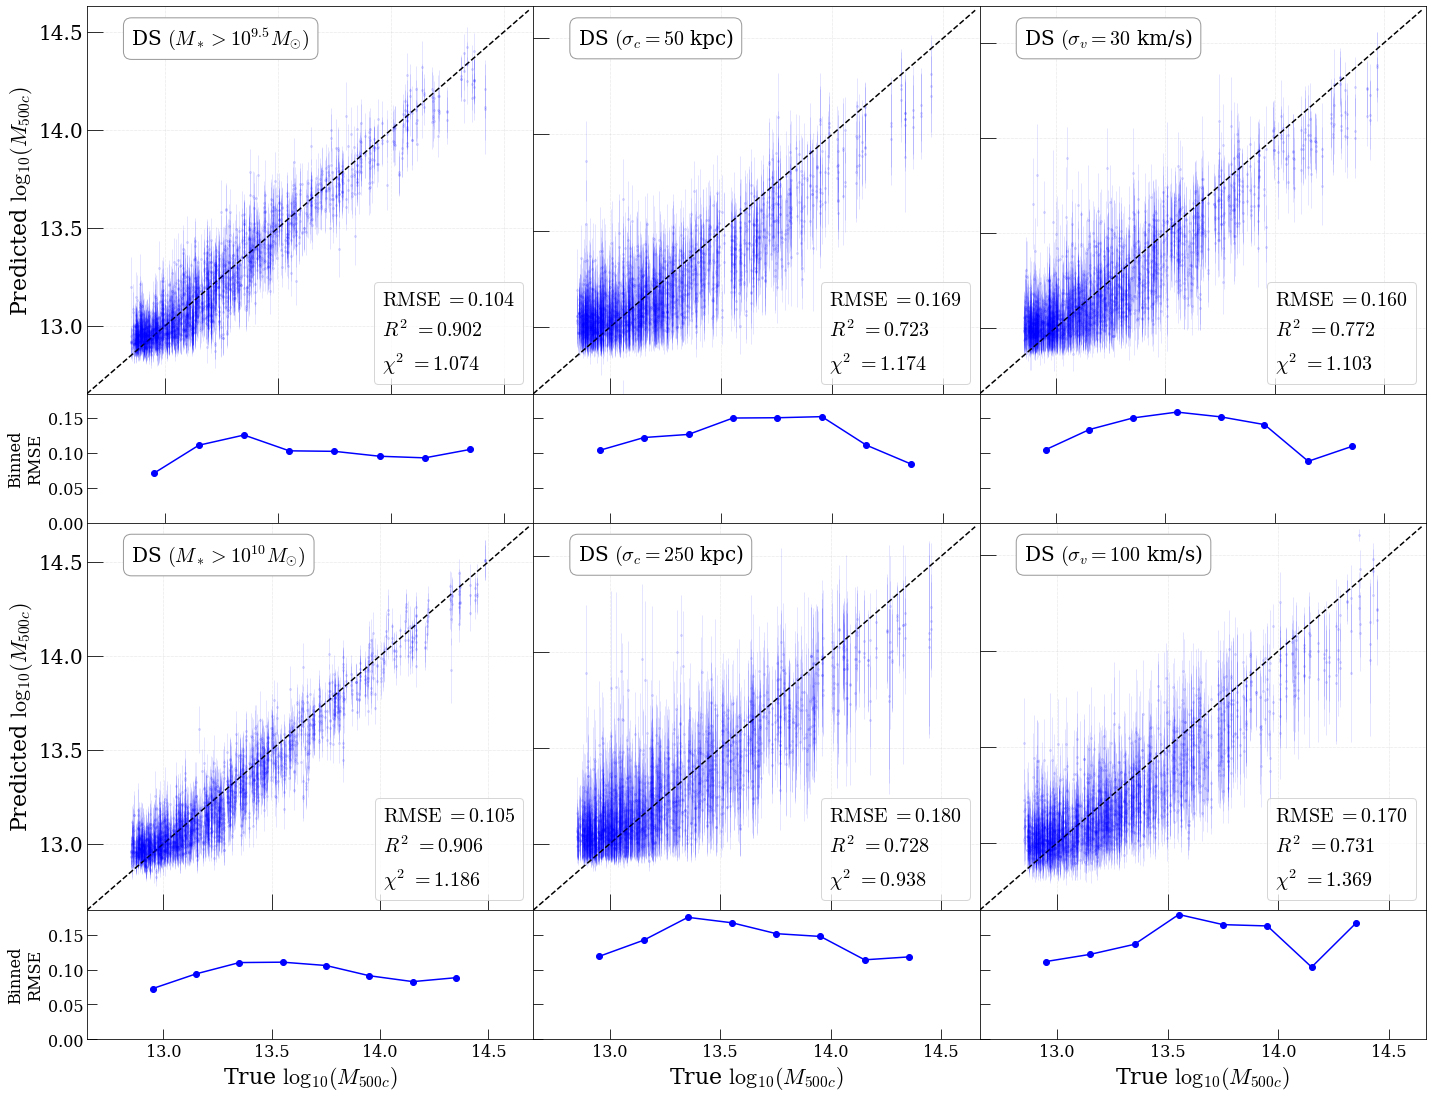

In [3]:
##### Figure 3 #####

data_dir = "predicted_values/"
true_dir = "true_values/"

plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

panels = [
    (r'DS $(M_* > 10^{9.5} M_{\odot})$','preds_deepsets_m500c_mass_cut_9.5.npy', 'ys_deepsets_m500c_mass_cut_9.5.npy', r'$\log_{10}(M_{500c})$', m500c_range),
    (r'DS $(\sigma_c = 50$ kpc)','preds_deepsets_m500c_pos_noise_50.npy', 'ys_deepsets_m500c_pos_noise_50.npy', r'$\log_{10}(M_{500c})$', m500c_range),
    (r'DS $(\sigma_v = 30$ km/s)','preds_deepsets_m500c_vel_noise_30.npy', 'ys_deepsets_m500c_vel_noise_30.npy', r'$\log_{10}(M_{500c})$', m500c_range),
    (r'DS $(M_* > 10^{10} M_{\odot})$','preds_deepsets_m500c_mass_cut_10.npy', 'ys_deepsets_m500c_mass_cut_10.npy', r'$\log_{10}(M_{500c})$', m500c_range),
    (r'DS $(\sigma_c = 250$ kpc)','preds_deepsets_m500c_pos_noise_250.npy', 'ys_deepsets_m500c_pos_noise_250.npy', r'$\log_{10}(M_{500c})$', m500c_range),
    (r'DS $(\sigma_v = 100$ km/s)','preds_deepsets_m500c_vel_noise_100.npy', 'ys_deepsets_m500c_vel_noise_100.npy', r'$\log_{10}(M_{500c})$', m500c_range)
]

nrows, ncols = 2, 3

bin_size = 0.2
reslo, reshi = 0.0, 0.185

fig = plt.figure(figsize=(8 * ncols, 9.5 * nrows))
outer = fig.add_gridspec(nrows, ncols, wspace=0.0, hspace=0.0)

for idx, (network, pred_file, true_file, param, param_range) in enumerate(panels):
    row, col = divmod(idx, ncols)

    inner = outer[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0)
    ax = fig.add_subplot(inner[0])
    ax_disp = fig.add_subplot(inner[1], sharex=ax)

    pred_array = np.load(data_dir + pred_file)
    true_array = np.load(true_dir + true_file)
    df = pd.DataFrame({
        'pred_value': pred_array[:, 0],
        'pred_unc':   pred_array[:, 1],
        'true_value': true_array,
    })

    y = df['pred_value'].values
    x = df['true_value'].values
    y_err = df['pred_unc'].values

    maxs, mins = np.max(x), np.min(x)
    window_range = (maxs - mins) * 0.25 / 2

    RMSE = np.nanmean(rmse(x, y))
    R2   = np.nanmean(r2_score(x, y))
    chi2 = np.nanmean(chi_squared(x, y, np.exp(y_err)))

    array_mask = np.zeros_like(x)
    array_mask[0:int( len(array_mask))] += 1
    np.random.shuffle(array_mask)
    for i in range(len(x)):
        if array_mask[i] == 1:
            ax.errorbar(x[i], y[i], np.exp(y_err[i]), linestyle='None', lw=1,
                        fmt='o', ms=2, elinewidth=1, capsize=0, alpha=0.1, c='blue')

    ax.plot([mins - window_range, maxs + window_range],
            [mins - window_range, maxs + window_range], 'k--')
    ax.text(
        0.10, 0.95, network,
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=20,
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='0.6',
            linewidth=1.0,
        )
    )
    ax.set_xlim(mins - window_range, maxs + window_range * 1.1)
    ax.set_ylim(mins - window_range, maxs + window_range * 1.1)
    ax.set_xticks([13.0, 13.5, 14.0, 14.5])
    ax.set_yticks([13.0, 13.5, 14.0, 14.5])
    ax.tick_params(axis='both', direction='in', top=False, right=False, length=16, labelsize=20)
    plt.setp(ax.get_xticklabels(), visible=False)  
    if col != 0:
        plt.setp(ax.get_yticklabels(), visible=False)

    line_RMSE, = ax.plot([], [], label=r'$\rm{RMSE}\ $' + f'$= {RMSE:.3f}$', color='none')
    line_R2,   = ax.plot([], [], label=r'$R^2\ $' + f'$= {R2:.3f}$', color='none')
    line_chi2, = ax.plot([], [], label=r'$\chi^2\ $' + f'$= {chi2:.3f}$', color='none')
    ax.legend(handlelength=0, handletextpad=0, loc='lower right', fontsize=20)
    ax.grid(True, which='major', axis='both', linestyle=':', linewidth=0.5, alpha=0.75)
    if col == 0:
        ax.set_ylabel(f"Predicted {param}", fontsize=22)

    # --- binned RMSE (dispersion) sub-panel ---
    residuals = y - x 
    bins = np.arange(mins, maxs + bin_size, bin_size)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    dispersion = []
    for i in range(len(bins) - 1):
        in_bin = (x >= bins[i]) & (x < bins[i + 1])
        r = residuals[in_bin]
        if len(r) > 10:
            sigma = np.std(r)
        else:
            sigma = np.nan
        dispersion.append(sigma)
    dispersion = np.array(dispersion)

    ax_disp.plot(bin_centers, dispersion, marker='o', color='blue')
    ax_disp.set_ylim(reslo, reshi)
    ax_disp.tick_params(axis='both', direction='in', top=False, right=False, length=10, labelsize=16)
    if row == nrows - 1:
        ax_disp.set_xlabel(f"True {param}", fontsize=22)
    else:
        plt.setp(ax_disp.get_xticklabels(), visible=False)
    if col == 0:
        ax_disp.set_ylabel("Binned\nRMSE", fontsize=16)
    else:
        plt.setp(ax_disp.get_yticklabels(), visible=False)

plt.show()

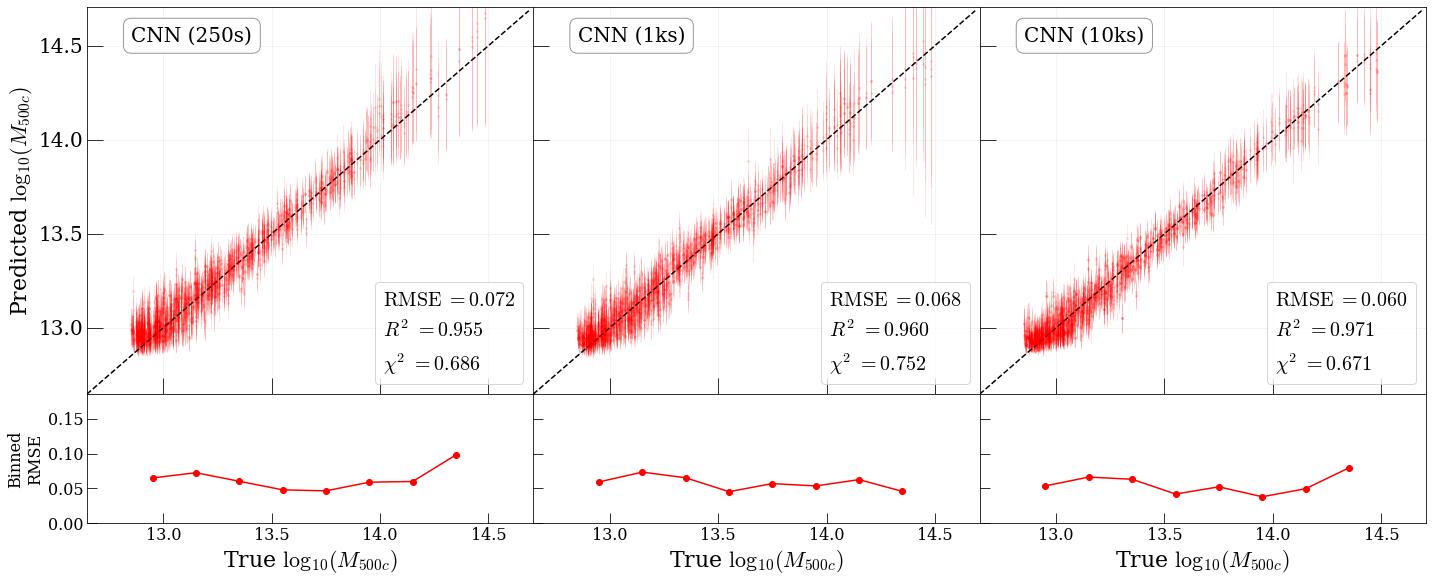

In [6]:
##### Figure 4 #####

data_dir = "predicted_values/"
true_dir = "true_values/"

plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

panels = [
    ('CNN (250s)','preds_cnn_m500c_0.250ks_0.5-2keV.npy', 'ys_cnn_m500c_0.250ks_0.5-2keV.npy', r'$\log_{10}(M_{500c})$', m500c_range,'red'),
    ('CNN (1ks)', 'preds_cnn_m500c_1ks_0.5-2keV.npy', 'ys_cnn_m500c_1ks_0.5-2keV.npy',r'$\log_{10}(M_{500c})$', m500c_range,'red'),
    ('CNN (10ks)','preds_cnn_m500c_10ks_0.5-2keV.npy','ys_cnn_m500c_10ks_0.5-2keV.npy',r'$\log_{10}(M_{500c})$', m500c_range,'red'),
]


nrows, ncols = 1, 3

bin_size = 0.2
reslo, reshi = 0.0, 0.185

fig = plt.figure(figsize=(8 * ncols, 9.5 * nrows))
outer = fig.add_gridspec(nrows, ncols, wspace=0.0, hspace=0.0)

for idx, (network, pred_file, true_file, param, param_range,color) in enumerate(panels):
    row, col = divmod(idx, ncols)

    inner = outer[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0)
    ax = fig.add_subplot(inner[0])
    ax_disp = fig.add_subplot(inner[1], sharex=ax)

    pred_array = np.load(data_dir + pred_file)
    true_array = np.load(true_dir + true_file)
    df = pd.DataFrame({
        'pred_value': pred_array[:, 0],
        'pred_unc':   pred_array[:, 1],
        'true_value': true_array,
    })

    y = df['pred_value'].values
    x = df['true_value'].values
    y_err = df['pred_unc'].values 

    maxs, mins = np.max(x), np.min(x)
    window_range = (maxs - mins) * 0.25 / 2

    RMSE = np.nanmean(rmse(x, y))
    R2   = np.nanmean(r2_score(x, y))
    chi2 = np.nanmean(chi_squared(x, y, np.exp(y_err)))

    array_mask = np.zeros_like(x)
    array_mask[0:int( len(array_mask))] += 1
    np.random.shuffle(array_mask)
    for i in range(len(x)):
        if array_mask[i] == 1:
            ax.errorbar(x[i], y[i], np.exp(y_err[i]), linestyle='None', lw=1,
                        fmt='o', ms=2, elinewidth=1, capsize=0, alpha=0.1, c=color)

    ax.plot([mins - window_range, maxs + window_range],
            [mins - window_range, maxs + window_range], 'k--')
    ax.text(
        0.10, 0.95, network,
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=20,
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='0.6',
            linewidth=1.0,
        )
    )
    ax.set_xlim(mins - window_range, maxs + window_range * 1.1)
    ax.set_ylim(mins - window_range, maxs + window_range * 1.1)
    ax.set_xticks([13.0, 13.5, 14.0, 14.5])
    ax.set_yticks([13.0, 13.5, 14.0, 14.5])
    ax.tick_params(axis='both', direction='in', top=False, right=False, length=16, labelsize=20)
    plt.setp(ax.get_xticklabels(), visible=False)  
    if col != 0:
        plt.setp(ax.get_yticklabels(), visible=False)

    line_RMSE, = ax.plot([], [], label=r'$\rm{RMSE}\ $' + f'$= {RMSE:.3f}$', color=color)
    line_R2,   = ax.plot([], [], label=r'$R^2\ $' + f'$= {R2:.3f}$', color=color)
    line_chi2, = ax.plot([], [], label=r'$\chi^2\ $' + f'$= {chi2:.3f}$', color=color)
    ax.legend(handlelength=0, handletextpad=0, loc='lower right', fontsize=20)
    ax.grid(True, which='major', axis='both', linestyle=':', linewidth=0.5, alpha=0.75)
    if col == 0:
        ax.set_ylabel(f"Predicted {param}", fontsize=22)

    # --- binned RMSE (dispersion) sub-panel ---
    residuals = y - x  
    bins = np.arange(mins, maxs + bin_size, bin_size)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    dispersion = []
    for i in range(len(bins) - 1):
        in_bin = (x >= bins[i]) & (x < bins[i + 1])
        r = residuals[in_bin]
        if len(r) > 10:
            sigma = np.std(r)
        else:
            sigma = np.nan
        dispersion.append(sigma)
    dispersion = np.array(dispersion)

    ax_disp.plot(bin_centers, dispersion, marker='o', color=color)
    ax_disp.set_ylim(reslo, reshi)
    ax_disp.tick_params(axis='both', direction='in', top=False, right=False, length=10, labelsize=16)
    if row == nrows - 1:
        ax_disp.set_xlabel(f"True {param}", fontsize=22)
    else:
        plt.setp(ax_disp.get_xticklabels(), visible=False)
    if col == 0:
        ax_disp.set_ylabel("Binned\nRMSE", fontsize=16)
    else:
        plt.setp(ax_disp.get_yticklabels(), visible=False)

plt.show()

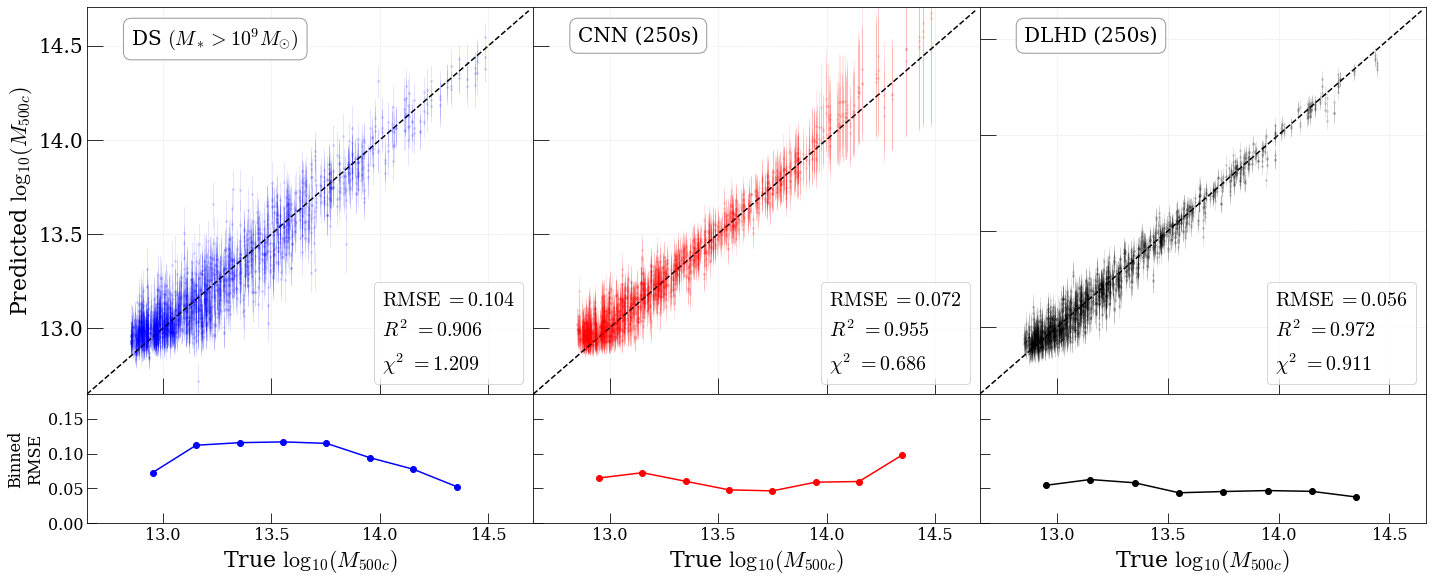

In [7]:
##### Figure 5 #####

data_dir = "predicted_values/"
true_dir = "true_values/"

plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

panels = [
    (r'DS $(M_* > 10^9 M_{\odot})$','preds_deepsets_m500c_mass_cut_9.npy', 'ys_deepsets_m500c_mass_cut_9.npy', r'$\log_{10}(M_{500c})$', m500c_range,'blue'),
    ('CNN (250s)', 'preds_cnn_m500c_0.250ks_0.5-2keV.npy', 'ys_cnn_m500c_0.250ks_0.5-2keV.npy',r'$\log_{10}(M_{500c})$', m500c_range,'red'),
    ('DLHD (250s)','preds_combined_full_m500c_0.250ks_0.5-2keV.npy','ys_combined_full_m500c_0.250ks_0.5-2keV.npy',r'$\log_{10}(M_{500c})$', m500c_range,'black'),
]



nrows, ncols = 1, 3

bin_size = 0.2
reslo, reshi = 0.0, 0.185

fig = plt.figure(figsize=(8 * ncols, 9.5 * nrows))
outer = fig.add_gridspec(nrows, ncols, wspace=0.0, hspace=0.0)

for idx, (network, pred_file, true_file, param, param_range,color) in enumerate(panels):
    row, col = divmod(idx, ncols)

    inner = outer[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0)
    ax = fig.add_subplot(inner[0])
    ax_disp = fig.add_subplot(inner[1], sharex=ax)

    pred_array = np.load(data_dir + pred_file)
    true_array = np.load(true_dir + true_file)
    df = pd.DataFrame({
        'pred_value': pred_array[:, 0],
        'pred_unc':   pred_array[:, 1],
        'true_value': true_array,
    })

    y = df['pred_value'].values
    x = df['true_value'].values
    y_err = df['pred_unc'].values 

    maxs, mins = np.max(x), np.min(x)
    window_range = (maxs - mins) * 0.25 / 2

    RMSE = np.nanmean(rmse(x, y))
    R2   = np.nanmean(r2_score(x, y))
    chi2 = np.nanmean(chi_squared(x, y, np.exp(y_err)))

    array_mask = np.zeros_like(x)
    array_mask[0:int( len(array_mask))] += 1
    np.random.shuffle(array_mask)
    for i in range(len(x)):
        if array_mask[i] == 1:
            ax.errorbar(x[i], y[i], np.exp(y_err[i]), linestyle='None', lw=1,
                        fmt='o', ms=2, elinewidth=1, capsize=0, alpha=0.1, c=color)

    ax.plot([mins - window_range, maxs + window_range],
            [mins - window_range, maxs + window_range], 'k--')
    ax.text(
        0.10, 0.95, network,
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=20,
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='0.6',
            linewidth=1.0,
        )
    )
    ax.set_xlim(mins - window_range, maxs + window_range * 1.1)
    ax.set_ylim(mins - window_range, maxs + window_range * 1.1)
    ax.set_xticks([13.0, 13.5, 14.0, 14.5])
    ax.set_yticks([13.0, 13.5, 14.0, 14.5])
    ax.tick_params(axis='both', direction='in', top=False, right=False, length=16, labelsize=20)
    plt.setp(ax.get_xticklabels(), visible=False)  
    if col != 0:
        plt.setp(ax.get_yticklabels(), visible=False)

    line_RMSE, = ax.plot([], [], label=r'$\rm{RMSE}\ $' + f'$= {RMSE:.3f}$', color=color)
    line_R2,   = ax.plot([], [], label=r'$R^2\ $' + f'$= {R2:.3f}$', color=color)
    line_chi2, = ax.plot([], [], label=r'$\chi^2\ $' + f'$= {chi2:.3f}$', color=color)
    ax.legend(handlelength=0, handletextpad=0, loc='lower right', fontsize=20)
    ax.grid(True, which='major', axis='both', linestyle=':', linewidth=0.5, alpha=0.75)
    if col == 0:
        ax.set_ylabel(f"Predicted {param}", fontsize=22)
        
    # --- binned RMSE (dispersion) sub-panel ---
    residuals = y - x  
    bins = np.arange(mins, maxs + bin_size, bin_size)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    dispersion = []
    for i in range(len(bins) - 1):
        in_bin = (x >= bins[i]) & (x < bins[i + 1])
        r = residuals[in_bin]
        if len(r) > 10:
            sigma = np.std(r)
        else:
            sigma = np.nan
        dispersion.append(sigma)
    dispersion = np.array(dispersion)

    ax_disp.plot(bin_centers, dispersion, marker='o', color=color)
    ax_disp.set_ylim(reslo, reshi)
    ax_disp.tick_params(axis='both', direction='in', top=False, right=False, length=10, labelsize=16)
    if row == nrows - 1:
        ax_disp.set_xlabel(f"True {param}", fontsize=22)
    else:
        plt.setp(ax_disp.get_xticklabels(), visible=False)
    if col == 0:
        ax_disp.set_ylabel("Binned\nRMSE", fontsize=16)
    else:
        plt.setp(ax_disp.get_yticklabels(), visible=False)

plt.show()

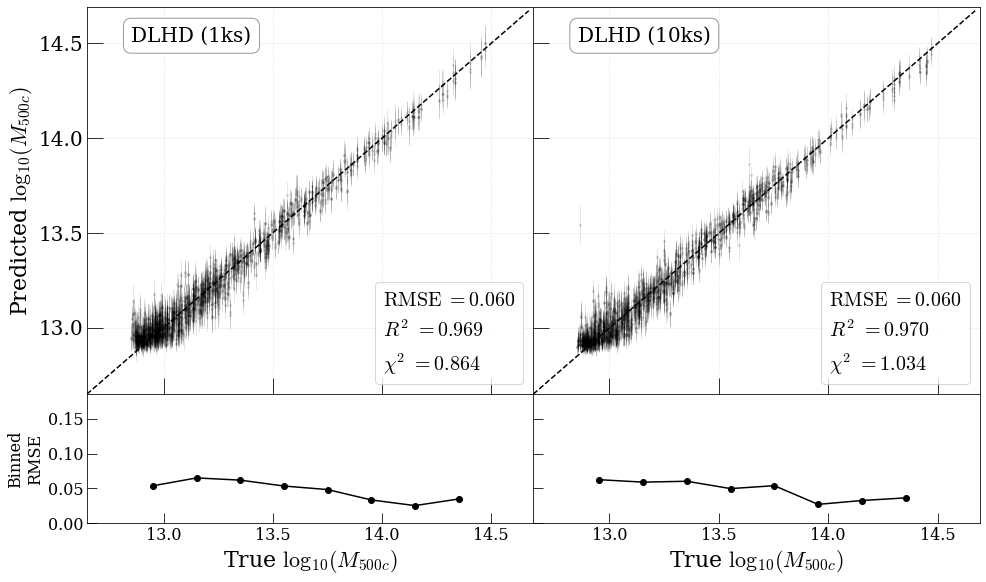

In [8]:
##### Figure 6 #####

data_dir = "predicted_values/"
true_dir = "true_values/"

plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

panels = [
    ('DLHD (1ks)','preds_combined_full_m500c_1ks_0.5-2keV.npy', 'ys_combined_full_m500c_1ks_0.5-2keV.npy', r'$\log_{10}(M_{500c})$', m500c_range,'black'),
    ('DLHD (10ks)', 'preds_combined_full_m500c_10ks_0.5-2keV.npy', 'ys_combined_full_m500c_10ks_0.5-2keV.npy',r'$\log_{10}(M_{500c})$', m500c_range,'black')
    
]



nrows, ncols = 1, 2

bin_size = 0.2
reslo, reshi = 0.0, 0.185

fig = plt.figure(figsize=(8 * ncols, 9.5 * nrows))
outer = fig.add_gridspec(nrows, ncols, wspace=0.0, hspace=0.0)

for idx, (network, pred_file, true_file, param, param_range,color) in enumerate(panels):
    row, col = divmod(idx, ncols)

    inner = outer[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0)
    ax = fig.add_subplot(inner[0])
    ax_disp = fig.add_subplot(inner[1], sharex=ax)

    pred_array = np.load(data_dir + pred_file)
    true_array = np.load(true_dir + true_file)
    df = pd.DataFrame({
        'pred_value': pred_array[:, 0],
        'pred_unc':   pred_array[:, 1],
        'true_value': true_array,
    })

    y = df['pred_value'].values
    x = df['true_value'].values
    y_err = df['pred_unc'].values 

    maxs, mins = np.max(x), np.min(x)
    window_range = (maxs - mins) * 0.25 / 2

    RMSE = np.nanmean(rmse(x, y))
    R2   = np.nanmean(r2_score(x, y))
    chi2 = np.nanmean(chi_squared(x, y, np.exp(y_err)))

    array_mask = np.zeros_like(x)
    array_mask[0:int( len(array_mask))] += 1
    np.random.shuffle(array_mask)
    for i in range(len(x)):
        if array_mask[i] == 1:
            ax.errorbar(x[i], y[i], np.exp(y_err[i]), linestyle='None', lw=1,
                        fmt='o', ms=2, elinewidth=1, capsize=0, alpha=0.1, c=color)

    ax.plot([mins - window_range, maxs + window_range],
            [mins - window_range, maxs + window_range], 'k--')
    ax.text(
        0.10, 0.95, network,
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=20,
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='0.6',
            linewidth=1.0,
        )
    )
    ax.set_xlim(mins - window_range, maxs + window_range * 1.1)
    ax.set_ylim(mins - window_range, maxs + window_range * 1.1)
    ax.set_xticks([13.0, 13.5, 14.0, 14.5])
    ax.set_yticks([13.0, 13.5, 14.0, 14.5])
    ax.tick_params(axis='both', direction='in', top=False, right=False, length=16, labelsize=20)
    plt.setp(ax.get_xticklabels(), visible=False)  
    if col != 0:
        plt.setp(ax.get_yticklabels(), visible=False)

    line_RMSE, = ax.plot([], [], label=r'$\rm{RMSE}\ $' + f'$= {RMSE:.3f}$', color=color)
    line_R2,   = ax.plot([], [], label=r'$R^2\ $' + f'$= {R2:.3f}$', color=color)
    line_chi2, = ax.plot([], [], label=r'$\chi^2\ $' + f'$= {chi2:.3f}$', color=color)
    ax.legend(handlelength=0, handletextpad=0, loc='lower right', fontsize=20)
    ax.grid(True, which='major', axis='both', linestyle=':', linewidth=0.5, alpha=0.75)
    if col == 0:
        ax.set_ylabel(f"Predicted {param}", fontsize=22)

    # --- binned RMSE (dispersion) sub-panel ---
    residuals = y - x  
    bins = np.arange(mins, maxs + bin_size, bin_size)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    dispersion = []
    for i in range(len(bins) - 1):
        in_bin = (x >= bins[i]) & (x < bins[i + 1])
        r = residuals[in_bin]
        if len(r) > 10:
            sigma = np.std(r)
        else:
            sigma = np.nan
        dispersion.append(sigma)
    dispersion = np.array(dispersion)

    ax_disp.plot(bin_centers, dispersion, marker='o', color=color)
    ax_disp.set_ylim(reslo, reshi)
    ax_disp.tick_params(axis='both', direction='in', top=False, right=False, length=10, labelsize=16)
    if row == nrows - 1:
        ax_disp.set_xlabel(f"True {param}", fontsize=22)
    else:
        plt.setp(ax_disp.get_xticklabels(), visible=False)
    if col == 0:
        ax_disp.set_ylabel("Binned\nRMSE", fontsize=16)
    else:
        plt.setp(ax_disp.get_yticklabels(), visible=False)


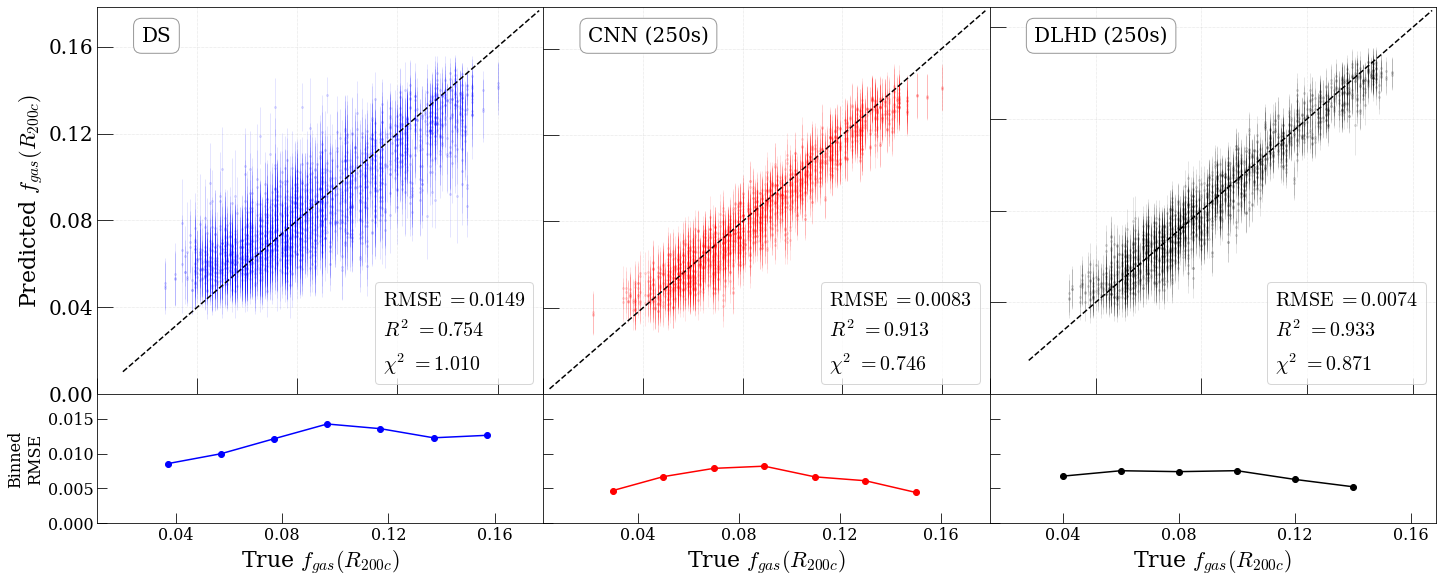

In [9]:
##### Figure 8 #####

data_dir = "predicted_values/"
true_dir = "true_values/"

plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

panels = [
    (r'DS','preds_deepsets_f_gas_R.npy', 'ys_deepsets_f_gas_R.npy', r'$f_{gas}(R_{200c})$', fgas_R_range,'blue'),
    ('CNN (250s)', 'preds_cnn_f_gas_R_0.250ks_0.5-2keV.npy', 'ys_cnn_f_gas_R_0.250ks_0.5-2keV.npy',r'$f_{gas}(R_{200c})$', fgas_R_range,'red'),
    ('DLHD (250s)','preds_combined_full_f_gas_R_0.250ks_0.5-2keV.npy','ys_combined_full_f_gas_R_0.250ks_0.5-2keV.npy',r'$f_{gas}(R_{200c})$', fgas_R_range,'black'),
]



nrows, ncols = 1, 3
bin_size = 0.02
reslo, reshi = 0.0, 0.0185


fig = plt.figure(figsize=(8 * ncols, 9.5 * nrows))
outer = fig.add_gridspec(nrows, ncols, wspace=0.0, hspace=0.0)

for idx, (network, pred_file, true_file, param, param_range,color) in enumerate(panels):
    row, col = divmod(idx, ncols)

    inner = outer[row, col].subgridspec(2, 1, height_ratios=[3, 1], hspace=0)
    ax = fig.add_subplot(inner[0])
    ax_disp = fig.add_subplot(inner[1], sharex=ax)

    pred_array = np.load(data_dir + pred_file)
    true_array = np.load(true_dir + true_file)
    df = pd.DataFrame({
        'pred_value': pred_array[:, 0],
        'pred_unc':   pred_array[:, 1],
        'true_value': true_array,
    })

    y = df['pred_value'].values
    x = df['true_value'].values
    y_err = df['pred_unc'].values 

    maxs, mins = np.max(x), np.min(x)
    window_range = (maxs - mins) * 0.25 / 2

    RMSE = np.nanmean(rmse(x, y))
    R2   = np.nanmean(r2_score(x, y))
    chi2 = np.nanmean(chi_squared(x, y, np.exp(y_err)))

    array_mask = np.zeros_like(x)
    array_mask[0:int( len(array_mask))] += 1
    np.random.shuffle(array_mask)
    for i in range(len(x)):
        if array_mask[i] == 1:
            ax.errorbar(x[i], y[i], np.exp(y_err[i]), linestyle='None', lw=1,
                        fmt='o', ms=2, elinewidth=1, capsize=0, alpha=0.1, c=color)

    ax.plot([mins - window_range, maxs + window_range],[mins - window_range, maxs + window_range], 'k--')
    ax.text(
        0.10, 0.95, network,
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=20,
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='0.6',
            linewidth=1.0,
        )
    )
    ax.set_xlim(mins - window_range, maxs + window_range * 1.1)
    ax.set_ylim(mins - window_range, maxs + window_range * 1.1)
    ax.set_xticks([0,0.04,0.08,0.12,0.16])
    ax.set_yticks([0,0.04,0.08,0.12,0.16])
    ax.tick_params(axis='both', direction='in', top=False, right=False, length=16, labelsize=20)
    plt.setp(ax.get_xticklabels(), visible=False)  
    if col != 0:
        plt.setp(ax.get_yticklabels(), visible=False)

    line_RMSE, = ax.plot([], [], label=r'$\rm{RMSE}\ $' + f'$= {RMSE:.4f}$', color=color)
    line_R2,   = ax.plot([], [], label=r'$R^2\ $' + f'$= {R2:.3f}$', color=color)
    line_chi2, = ax.plot([], [], label=r'$\chi^2\ $' + f'$= {chi2:.3f}$', color=color)
    ax.legend(handlelength=0, handletextpad=0, loc='lower right', fontsize=20)
    ax.grid(True, which='major', axis='both', linestyle=':', linewidth=0.5, alpha=0.75)
    if col == 0:
        ax.set_ylabel(f"Predicted {param}", fontsize=22)
        
    # --- binned RMSE (dispersion) sub-panel ---
    residuals = y - x  
    bins = np.arange(mins, maxs + bin_size, bin_size)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    dispersion = []
    for i in range(len(bins) - 1):
        in_bin = (x >= bins[i]) & (x < bins[i + 1])
        r = residuals[in_bin]
        if len(r) > 10:
            sigma = np.std(r)
        else:
            sigma = np.nan
        dispersion.append(sigma)
    dispersion = np.array(dispersion)

    ax_disp.plot(bin_centers, dispersion, marker='o', color=color)
    ax_disp.set_ylim(reslo, reshi)
    ax_disp.tick_params(axis='both', direction='in', top=False, right=False, length=10, labelsize=16)
    if row == nrows - 1:
        ax_disp.set_xlabel(f"True {param}", fontsize=22)
    else:
        plt.setp(ax_disp.get_xticklabels(), visible=False)
    if col == 0:
        ax_disp.set_ylabel("Binned\nRMSE", fontsize=16)
    else:
        plt.setp(ax_disp.get_yticklabels(), visible=False)

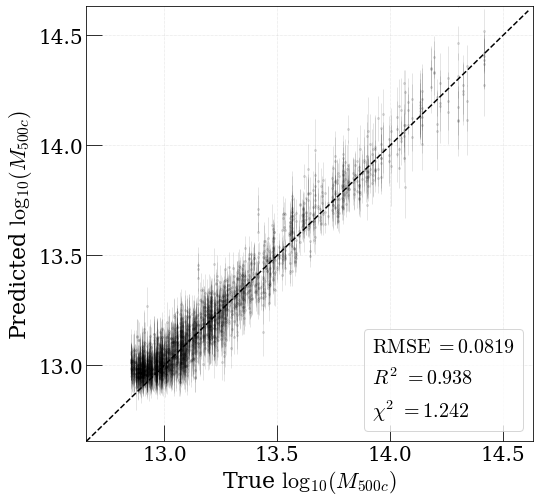

In [10]:
### not a figure in the paper, just using this code to gather statistics from individual runs ###

data_dir = "predicted_values/"
true_dir = "true_values/"

plt.rcParams.update({
    "mathtext.fontset": "cm",
    "font.family": "serif",
})

panels = [
    (r'','preds_combined_solo_m500c_0.250ks_0.5-2keV.npy', 'ys_combined_solo_m500c_0.250ks_0.5-2keV.npy', r'$\log_{10}(M_{500c})$', m500c_range)
]

nrows, ncols = 1, 1  

fig, axes = plt.subplots(nrows, ncols, figsize=(8*ncols, 8*nrows),
                          sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for idx, (network, pred_file, true_file, param, param_range) in enumerate(panels):
    row, col = divmod(idx, ncols)
    ax = axes[row, col]

    pred_array = np.load(data_dir + pred_file)
    true_array = np.load(true_dir + true_file)
    df = pd.DataFrame({
        'pred_value': pred_array[:, 0],
        'pred_unc':   pred_array[:, 1],
        'true_value': true_array,
    })

    y = df['pred_value'].values
    x = df['true_value'].values
    y_err = df['pred_unc'].values 

    maxs, mins = np.max(x), np.min(x)
    window_range = (maxs - mins) * 0.25 / 2

    RMSE = np.nanmean(rmse(x, y))
    R2   = np.nanmean(r2_score(x, y))
    chi2 = np.nanmean(chi_squared(x, y, np.exp(y_err)))

    array_mask = np.zeros_like(x)
    array_mask[0:int( len(array_mask))] += 1
    np.random.shuffle(array_mask)
    for i in range(len(x)):
        if array_mask[i] == 1:
            ax.errorbar(x[i], y[i], np.exp(y_err[i]), linestyle='None', lw=1,
                        fmt='o', ms=2, elinewidth=1, capsize=0, alpha=0.1, c='black')

    ax.plot([mins - window_range, maxs + window_range],
            [mins - window_range, maxs + window_range], 'k--')
    ax.text(
        0.10, 0.95, network,                 
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=20,
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='0.6',
            linewidth=1.0,
        )
    )
    ax.set_xlim(mins - window_range, maxs + window_range * 1.1)
    ax.set_ylim(mins - window_range, maxs + window_range * 1.1)
    ax.set_xticks([13.0, 13.5, 14.0, 14.5])
    ax.set_yticks([13.0, 13.5, 14.0, 14.5])
    ax.tick_params(axis='both', direction='in', top=False, right=False, length=16, labelsize=20)

    line_RMSE, = ax.plot([], [], label=r'$\rm{RMSE}\ $' + f'$= {RMSE:.4f}$', color='none')
    line_R2,   = ax.plot([], [], label=r'$R^2\ $' + f'$= {R2:.3f}$', color='none')
    line_chi2, = ax.plot([], [], label=r'$\chi^2\ $' + f'$= {chi2:.3f}$', color='none')
    ax.legend(handlelength=0, handletextpad=0, loc='lower right', fontsize=20)
    ax.grid(True, which='major',axis='both',linestyle=':',linewidth=0.5,alpha=0.75)
#     ax.set_box_aspect(1)
    if row == nrows - 1:
        ax.set_xlabel(f"True {param}",fontsize=22)
    if col == 0:
        ax.set_ylabel(f"Predicted {param}",fontsize=22)

for idx in range(len(panels), nrows * ncols):
    row, col = divmod(idx, ncols)
    axes[row, col].set_visible(False)

fig.subplots_adjust(wspace=0, hspace=0)
plt.show()

In [ ]:
### Naive combination

DS_data = np.load('preds/preds_deepsets_m500c_mass_cut_9.npy')
DS_true = np.load('ys/ys_deepsets_m500c_mass_cut_9.npy')
CNN_data = np.load('preds/preds_cnn_m500c_0.250ks_0.5-2keV.npy')
CNN_true = np.load('ys/ys_cnn_m500c_0.250ks_0.5-2keV.npy')
DLHD_data = np.load('preds/preds_combined_full_m500c_0.250ks_0.5-2keV.npy')
DLHD_true = np.load('ys/ys_combined_full_m500c_0.250ks_0.5-2keV.npy')

naive_data = np.concatenate((DS_data,CNN_data))
naive_true = np.concatenate((DS_true,CNN_true))

def compute_stats(data,true):
    RMSE = np.nanmean(rmse(data[:,0], true))
    R2   = np.nanmean(r2_score(data[:,0], true))
    chi2 = np.nanmean(chi_squared(data[:,0], true, np.exp(data[:,1])))
    print(f'scatter = {RMSE : .3f}')
    print(f'R2 = {R2:.3f}')
    print(f'chi2 = {chi2:.3f}')
    
print('----- DS -----')
compute_stats(DS_data,DS_true)
print('----- CNN -----')
compute_stats(CNN_data,CNN_true)
print('----- Naive -----')
compute_stats(naive_data,naive_true)
print('----- DLHD -----')
compute_stats(DLHD_data,DLHD_true)